In [2]:
# init
import importlib, sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

from tqdm import tqdm

Textwidth: float = 4.25279  # in
Textheight: float = 6.85173  # in

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic("config", "InlineBackend.rc = {'figure.dpi': 300}")

# Amplitude Study @ 18.3 GHz (raw)

In [11]:
# load data
data = np.load("amp_18.3GHz/eva.npz")

Vbias_mV = data["Vbias_mV"]
Ibias_nA = data["Ibias_nA"]
Aout_mV = data["Aout_mV"]
dGexp_G0 = data["dGexp_G0"]
dRexp_R0 = data["dRexp_R0"]
Iexp_nA = data["Iexp_nA"]
nu_GHz = data["nu_GHz"]

In [12]:
# restoring dimensions
eta = 0.002173  # (3)
GN_G0: float = 0.18877592218372993
Delta_meV: float = 0.19345000789195935

Aintrest_mV = (
    np.array([0, 0.96586225, 1.93172449, 3.09075919, 4.05662144])
    / (eta)
    * (sc.h_pVs * nu_GHz)
)

Vbiaslim = (-0.5 * Delta_meV, 4.5 * Delta_meV)
Abiaslim = (0, 700)
Ibiaslim = (
    -0.5 * (GN_G0 * sc.G0_muS * Delta_meV),
    4.5 * (GN_G0 * sc.G0_muS * Delta_meV),
)
Ilim = (-0.05 * (GN_G0 * sc.G0_muS * Delta_meV), 4.5 * (GN_G0 * sc.G0_muS * Delta_meV))
dGlim = (-0.05 * GN_G0, 4.5 * GN_G0)
dRlim = (-0.05 / GN_G0, 4.5 / GN_G0)

Vlabel = "$V\\,\\mathrm{(mV)}$"
Alabel = "$A_\\mathrm{out}\\,\\mathrm{(mV)}$"
Ilabel = "$I\\,\\mathrm{(nA)}$"
dGlabel = r"$\mathrm{d}I/\mathrm{d}V\,/\,G_\mathrm{N}$"
dRlabel = r"$\mathrm{d}V/\mathrm{d}I\,\cdot\,G_\mathrm{N}$"

In [13]:
# export the composite plots
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

exports = export_amplitude_maps_thesis(
    Vbias=Vbias_mV,
    Abias=Aout_mV,
    Ibias=Ibias_nA,
    Iexp=Iexp_nA,
    dGexp=dGexp_G0,
    dRexp=dRexp_R0,
    waterfall_traces=Aintrest_mV,
    Vbiaslim=Vbiaslim,
    Abiaslim=Abiaslim,
    Ibiaslim=Ibiaslim,
    Ilim=Ilim,
    dGlim=dGlim,
    dRlim=dRlim,
    Vbiasticks=None,
    Abiasticks=None,
    Ibiasticks=None,
    Iticks=None,
    dGticks=None,
    dRticks=None,
    Vlabel=Vlabel,
    Alabel=Alabel,
    Ilabel=Ilabel,
    dGlabel=dGlabel,
    dRlabel=dRlabel,
    name="raw",
    sub_dir="tunnelbarrier/highres/amp_18.3GHz/",
)

ValueError: Error measuring {\sffamily\fontsize{7.000000}{8.400000}\selectfont\catcode`\^=\active\def^{\ifmmode\sp\else\^{}\fi}\catcode`\%=\active\def%{\%}0.0}
LaTeX Output:
! Interruption.
<*> 
    {\catcode`\^=\active\catcode`\%=\active\sbox0{{\sffamily\fontsize{7.0000...
No pages of output.
Transcript written on texput.log.


# Amplitude Study @ 18.3 GHz (cal)

In [ ]:
# load data
data = np.load("amp_18.3GHz/cal.npz")

Vbias = data["Vbias"]
Ibias = data["Ibias"]
Abias = data["Abias"]
dGexp = data["dGexp"]
dRexp = data["dRexp"]
Iexp = data["Iexp"]
nu_GHz = data["nu_GHz"]
GN_G0 = data["GN_G0"]
Delta_meV = data["Delta_meV"]

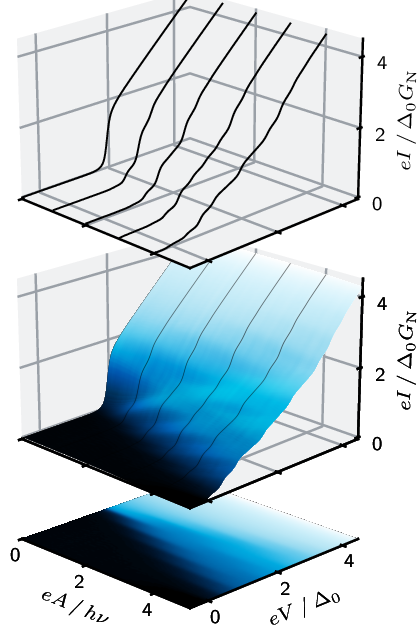

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/amp_18GHz/cal_iv/main.png

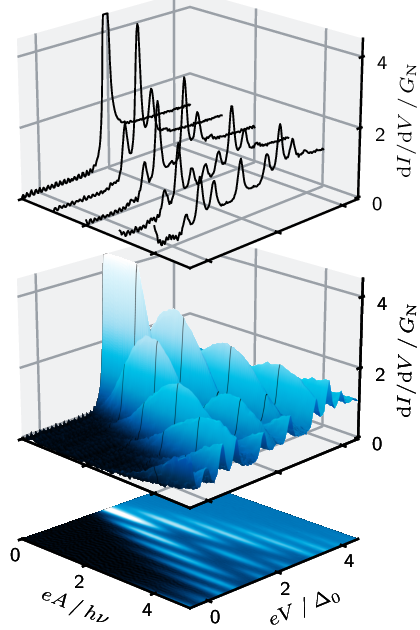

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/amp_18GHz/cal_didv/main.png

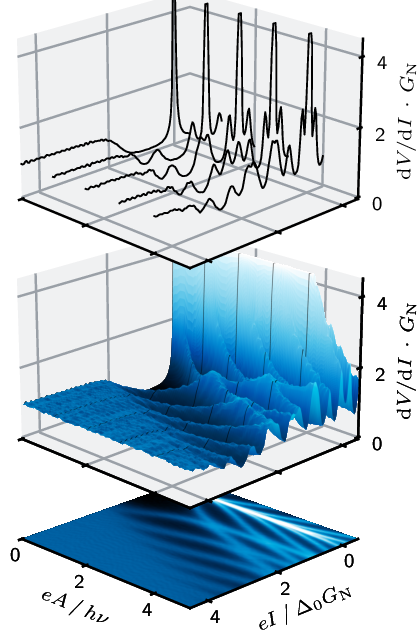

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/amp_18GHz/cal_dvdi/main.png

In [ ]:
# export the composite plots
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

exports = export_amplitude_maps_thesis(
    Vbias=Vbias,
    Abias=Abias,
    Ibias=Ibias,
    Iexp=Iexp,
    dGexp=dGexp,
    dRexp=dRexp,
    waterfall_traces=[0.0, 1.0, 2.0, 3.0, 4.0],
    name="cal",
    sub_dir="tunnelbarrier/highres/amp_18.3GHz",
)

# Amplitude Study @ 18.3 GHz (sim)

In [5]:
# load data
data = np.load("amp_18.3GHz/sim.npz")

Vbias = data["Vbias"]
Ibias = data["Ibias"]
Abias = data["Abias"]
Isim = data["Isim"]
dGsim = data["dGsim"]
dRsim = data["dRsim"]
nu_GHz = data["nu_GHz"]
GN_G0 = data["GN_G0"]
Delta_meV = data["Delta_meV"]

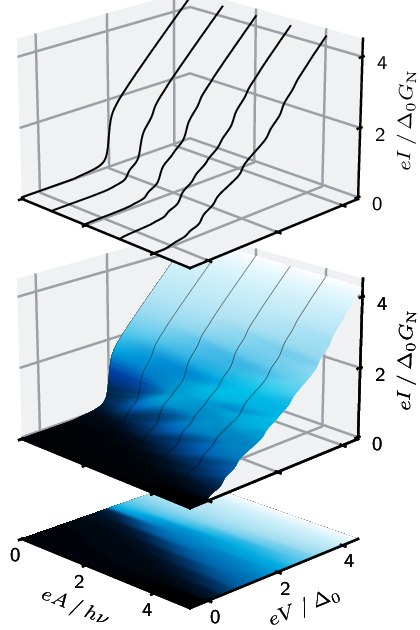

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/amp_18.3GHz/sim_iv/main.png

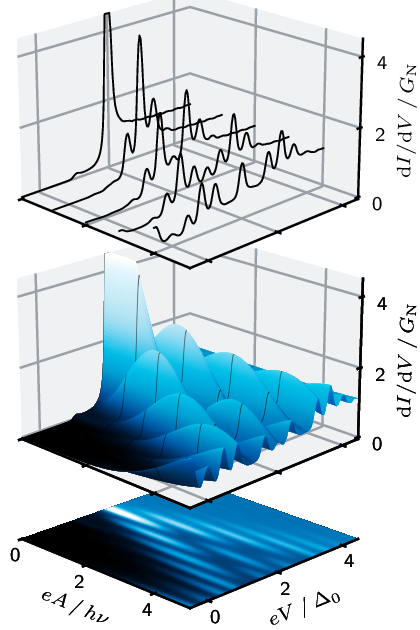

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/amp_18.3GHz/sim_didv/main.png

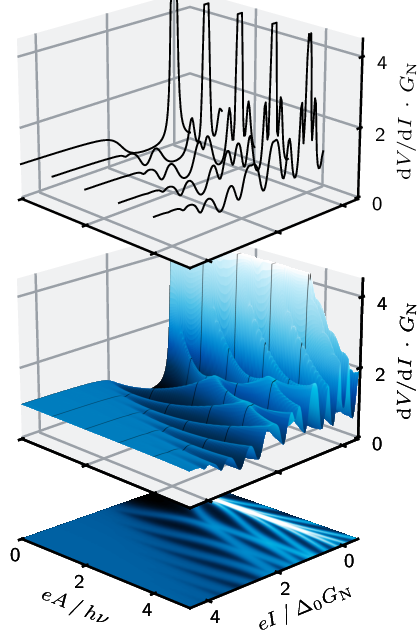

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/amp_18.3GHz/sim_dvdi/main.png

In [6]:
# export the composite plots
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

exports = export_amplitude_maps_thesis(
    Vbias=Vbias,
    Abias=Abias,
    Ibias=Ibias,
    Iexp=Isim,
    dGexp=dGsim,
    dRexp=dRsim,
    waterfall_traces=[0.0, 1.0, 2.0, 3.0, 4.0],
    name="sim",
    sub_dir="tunnelbarrier/highres/amp_18.3GHz",
)

# Amplitude Study @ 18.3 GHz (fit)

In [ ]:
# load data
data = np.load("amp_18GHz/fit.npz")

Aout_mV = data["Aout_mV"]
Afit_mV = data["Afit_mV"]
uAfit_mV = data["uAfit_mV"]
Tfit_K = data["Tfit_K"]
uTfit_K = data["uTfit_K"]
nu_GHz = data["nu_GHz"]
GN_G0 = data["GN_G0"]
Delta_meV = data["Delta_meV"]

In [12]:
figsize = (1.4, 1.2)
fig, ax = sc.get_figure(
    figsize=figsize,
    padding=(0.18, 0.2),
)

ax.plot(
    Aout_mV * 1e-3,
    Afit_mV / (nu_GHz * sc.h_pVs),
)

xlabel = "$A_\\mathrm{out}\\ \\mathrm{(mV)}$"
ylabel = "$eA\\,/\\,h\\nu$"
title = "tunnelbarrier/highres/amp_18GHz/fit"

sc.theory_layout(fig, ax, title, xlabel, ylabel)